In [34]:
import numpy as np
from scipy import stats
import scipy

In [2]:
X = np.array([0.8, 0.6, 0.3, -0.1, 1.1, -0.2, 0.3, 0.5, 0.5, 0.3])

In [3]:
X.shape[0]

10

In [4]:
cl = 0.8

In [5]:
ci_low, ci_high = stats.t.interval(confidence=cl,
                                   df=X.shape[0] - 1,
                                   loc=X.mean(),
                                   scale=X.std(ddof=1)/np.sqrt(X.shape[0]))

ci_low, ci_high

(np.float64(0.24067701164572183), np.float64(0.5793229883542781))

In [6]:
def binary_num(size):
    n = np.arange(0, 2**size)
    col = np.arange(size)[::-1]
    binary_n = (n[:, None] & (1 << col) > 0).astype(int)

    return 2 * binary_n - 1

In [9]:
centered_X = X - X.mean()
all_X = centered_X * binary_num(10)

all_X_mean = all_X.mean(axis=1)

In [10]:
np.percentile(all_X_mean, [10, 90]) + X.mean()

array([0.26, 0.56])

In [11]:
(all_X_mean + X.mean() < 3.5).sum()

np.int64(1024)

In [12]:
# X1, X2 = np.array([29.9, 11.4, 25.3, 16.5, 21.1]), np.array([26.6, 23.7, 28.5, 14.2, 17.9, 24.3])
X1, X2 = np.array([30, 29, 30, 29]), np.array([32, 31, 31, 30]) 
# X1, X2 = np.array([3,1]), np.array([5,5,8])

In [13]:
stats.ttest_ind(X1, X2)

TtestResult(statistic=np.float64(-3.0), pvalue=np.float64(0.024008196755730942), df=np.float64(6.0))

In [14]:
diff_mean = X2.mean() - X1.mean()

In [15]:
diff_mean

np.float64(1.5)

In [16]:
s1 = X1.std(ddof=1)
s2 = X2.std(ddof=1)
s = np.sqrt((s1**2 * (X1.shape[0]-1) + s2**2 * (X2.shape[0]-1))/(X1.shape[0] + X2.shape[0] - 2))

In [17]:
s * np.sqrt(1/X1.shape[0] + 1/X2.shape[0])

np.float64(0.5000000000000001)

In [18]:
cl=0.95

In [19]:
t = stats.t.isf((1-cl)/2, df=X1.shape[0] + X2.shape[0] - 2)
t

np.float64(2.4469118511449692)

In [20]:
diff_mean + t * (s * np.sqrt(1/X1.shape[0] + 1/X2.shape[0]))

np.float64(2.723455925572485)

In [21]:
diff_mean - t * (s * np.sqrt(1/X1.shape[0] + 1/X2.shape[0]))

np.float64(0.27654407442751516)

In [22]:
s = np.sqrt(s1**2/X1.shape[0] + s2**2/X2.shape[0])
s

np.float64(0.5)

In [23]:
df = s**4/((s1**2/X1.shape[0])**2/(X1.shape[0]-1)+(s2**2/X2.shape[0])**2/(X2.shape[0]-1))
df

np.float64(5.4)

In [24]:
stats.t.interval(cl, df=df, loc=diff_mean, scale=s)

(np.float64(0.24282399250719977), np.float64(2.7571760074928005))

In [25]:
mpgs = np.array([20.4, 19.3, 22.0, 17.5, 14.3])

In [26]:
stats.chisquare(mpgs)

Power_divergenceResult(statistic=np.float64(1.868449197860962), pvalue=np.float64(0.7599382668521665))

In [27]:
1/(stats.chi2.isf(0.025, df=4, loc=0, scale=1) / 4 / mpgs.std(ddof=1))

np.float64(1.0609090115253363)

In [28]:
1/(stats.chi2.isf(0.975, df=4, loc=0, scale=1)/ 4 / mpgs.std(ddof=1))

np.float64(24.40454270780428)

In [29]:
stats.chi2.isf(0.975, df=4, loc=0, scale=1)

np.float64(0.4844185570879302)

In [30]:
stats.f.isf(0.1, dfn=12, dfd=9)

np.float64(2.378884864462852)

In [31]:
np.log10(0.142/0.043)

np.float64(0.51881988880347)

In [32]:
np.log(0.142/0.043)

np.float64(1.1946269419076982)

In [35]:
scipy.special.binom(8,4)

np.float64(70.0)

In [36]:
stats.binom.stats(5, .8)

(np.float64(4.0), np.float64(0.7999999999999994))

In [37]:
stats.binom.cdf(3, 5, 0.5) - stats.binom.sf(3, 5, 0.5)

np.float64(0.625)

In [38]:
stats.norm.sf(15-0.5, loc=10, scale=np.sqrt(0.5*0.5*20))

np.float64(0.0220856724542213)

In [39]:

stats.binom.interval(0.95, 20, 0.8, loc=0.)

(np.float64(12.0), np.float64(19.0))

In [40]:
stats.binom.sf(10, 43, 0.5)

np.float64(0.9996969466843666)

In [41]:
stats.norm.sf(10.5, loc=43*0.5, scale=np.sqrt(43*0.5*.5))

np.float64(0.9996031299567194)

In [42]:
p=0.475
stats.norm.sf(36.5, loc=100*p, scale=np.sqrt(100*p*(1-p)))

np.float64(0.9861939951748339)

In [43]:
stats.binom.sf(37, 100, 0.475)

np.float64(0.9779309528150707)

In [44]:
stats.norm.isf(0.05)

np.float64(1.6448536269514729)

In [45]:
moth = np.array([[20,-5,10,15,25,5,10],
                 [14,-3,11,15,17,14,6]])

In [46]:
np.std(moth, axis=1, ddof=1) / np.sqrt(7)

array([3.73437789, 2.62639662])

In [47]:
stats.sem(moth, axis=1)

array([3.73437789, 2.62639662])

In [48]:
motha = np.array([40, 35,5,80,50,95,45])/100

In [49]:
motha_trans = np.arcsin(np.sqrt(motha)) / np.pi * 180

In [50]:
mothb = np.array([60,30,15,95,75,100,55])/100

In [51]:
mothb_trans = np.arcsin(np.sqrt(mothb)) / np.pi * 180

In [52]:
mothb_trans - motha_trans

array([11.53695903, -3.06028768,  9.86553162, 13.6440848 , 15.        ,
       12.92096638,  5.73917048])

In [53]:
stats.sem(mothb_trans - motha_trans)

np.float64(2.3664814450936795)

In [54]:
stats.chi2.sf(1, df=9)

np.float64(0.9994375026978325)

## Exercise 5.19

In [ ]:
n_raisins = np.array([43,46,50,40,38,29,31,35,41,52,48,37])

In [82]:
np.square(n_raisins - 36).sum()

np.int64(866)

In [84]:
stats.chi2.sf(np.square(n_raisins - 36).sum(), df=12, scale=36)

np.float64(0.019989976219464748)

In [86]:
stats.chi2.sf(np.square(n_raisins.sum() - 36 * 12), df=1, scale=36*12)

np.float64(0.00526224246280523)

In [87]:
stats.chi2.sf(np.square(n_raisins - 40.83).sum(), df=12-1, scale=40.83)

np.float64(0.21453789347376173)

In [ ]:
n_raisins_sqrt = np.sqrt(n_raisins)

In [85]:
n_raisins_sqrt_expect = stats.poisson.expect(np.sqrt, (36,))
n_raisins_sqrt_expect, stats.t.sf((n_raisins_sqrt.mean()-n_raisins_sqrt_expect), df=12, loc=0, scale=0.25)

(np.float64(5.97890340202872), np.float64(0.07366362141423981))

In [88]:
stats.t.sf(np.sqrt(n_raisins.sum()), df=1, loc=stats.poisson.expect(np.sqrt, (36*12,)), scale=0.25)

np.float64(0.057977147970522586)

In [67]:
n_raisins_sqrt_expect = stats.poisson.expect(np.sqrt, (40.83,))
stats.t.sf((n_raisins_sqrt.mean()-n_raisins_sqrt_expect)/0.25, df=12, loc=0, scale=1)

np.float64(0.5060781665451427)

## Exercise 5.20

In [89]:
tv_repair = np.array([[111, 162],
                      [85, 54]])

In [90]:
stats.contingency.expected_freq(tv_repair)

array([[129.87378641, 143.12621359],
       [ 66.12621359,  72.87378641]])

In [91]:
stats.chi2_contingency(tv_repair)

Chi2ContingencyResult(statistic=np.float64(14.696086692978973), pvalue=np.float64(0.00012630837982085055), dof=1, expected_freq=array([[129.87378641, 143.12621359],
       [ 66.12621359,  72.87378641]]))

## Questions 5.3

In [94]:
a, b = np.array([3,8,4,2,6]), np.array([5,12,11,10,9])

### paired by stats.ttest.rel method

In [175]:
stats.ttest_rel(a,b, alternative='less')

TtestResult(statistic=np.float64(-4.146568442790528), pvalue=np.float64(0.007150021698561001), df=np.int64(4))

In [107]:
stats.ttest_rel(a,b).confidence_interval()

ConfidenceInterval(low=np.float64(-8.013967570731996), high=np.float64(-1.5860324292680028))

In [252]:
stats.t.isf((0.025, 0.975), df=4, loc=-4.8, scale=1.34)

array([-1.07956356, -8.52043644])

### unpaired by stats.ttest.ind method

In [228]:
stats.ttest_ind(a,b,equal_var=True, alternative='less')

TtestResult(statistic=np.float64(-2.9654499034330346), pvalue=np.float64(0.008997880952412203), df=np.float64(8.0))

In [126]:
stats.ttest_ind(a,b, equal_var=True).confidence_interval()

ConfidenceInterval(low=np.float64(-8.532593774781315), high=np.float64(-1.0674062252186856))

### paired test manually

In [110]:
d = a - b

In [111]:
((d - d.mean())**2).sum()/20

np.float64(1.34)

In [112]:
stats.t.isf(0.025, df=4)

np.float64(2.7764451051977996)

In [114]:
d.mean() - stats.t.isf(0.025, df=4) * np.sqrt(((d - d.mean())**2).sum()/20), d.mean() + stats.t.isf(0.025, df=4) * np.sqrt(((d - d.mean())**2).sum()/20)

(np.float64(-8.013967570731998), np.float64(-1.586032429268002))

### unpaired test manually

In [116]:
sa, sb= np.std(a, ddof=1), np.std(b, ddof=1)
sa, sb

(np.float64(2.4083189157584592), np.float64(2.701851217221259))

In [117]:
s = np.sqrt((4*sa**2 + 4*sb**2) / 8)

In [119]:
stats.t.isf(0.025, df=8)

np.float64(2.3060041352041662)

In [127]:
a.mean()-b.mean() - 2.306 * s * np.sqrt(0.4), a.mean()-b.mean() + 2.306 * s * np.sqrt(0.4), 

(np.float64(-8.532587081368632), np.float64(-1.0674129186313688))

### verify intervals using a randomized distribution

In [187]:
ab = np.concat((a,b))

In [188]:
ab

array([ 3,  8,  4,  2,  6,  5, 12, 11, 10,  9])

In [213]:
ab_diffs = np.array([])
ab_diffs_un = np.array([])
for i in range(100000):
    ab = np.concat((a,b))
    np.random.shuffle(ab)
    ab_diff = (ab[:5] - ab[5:]).mean()
    ab_diff_un = ab[:5].mean() - ab[5:].mean()
    ab_diffs = np.append(ab_diffs, ab_diff)
    ab_diffs_un = np.append(ab_diffs_un, ab_diff_un)

In [248]:
(ab_diffs <= -4.8).sum() / 100000, (ab_diffs_un <= -4.8).sum() / 100000 # one tail

(np.float64(0.0159), np.float64(0.0159))

In [242]:
stats.ttest_ind(a, b, alternative='less', method=scipy.stats.PermutationMethod())

TtestResult(statistic=np.float64(-2.9654499034330346), pvalue=np.float64(0.015873015873015872), df=np.float64(8.0))

In [250]:
np.percentile(ab_diffs - 4.8, (2.5, 97.5))

array([-9.2, -0.4])

## Question 5.6

In [257]:
# assume it is poission distribution and it happens with a fixed possbility within a certain time period
p = 0.01 # possibility per second
t = 60 # 60 seconds
signals = stats.poisson.rvs(p*t, size=127)

In [258]:
((signals - signals.mean())**2).sum() / signals.mean()

np.float64(115.02941176470587)

In [565]:
stats.chi2.sf(115, df=125)

np.float64(0.728302473025131)

## Problems for Part I

### Whether or not specifically asked, the reader should always 
* (1) plot the data in any potentially useful way, 
* (2) state the assumptions made, 
* (3) comment on the appropriateness of the these assumptions
* (4) consider alternative analysis

### 1

In [261]:
a1 = np.array([5,4,8,6,7,8])

In [ ]:
a1.mean(), a1.var(ddof=1)

(np.float64(6.333333333333333), np.float64(2.6666666666666665))

### 2

In [263]:
a2 = np.array([12560, 12900, 12850, 12710])

In [264]:
a2.mean(), a2.var(ddof=1), a2.std(ddof=1)

(np.float64(12755.0),
 np.float64(23366.666666666668),
 np.float64(152.86159317064136))

### 3

In [265]:
a3 = np.array([1.0250, 1.0252, 1.0249, 1.0249])

In [266]:
a3.std(ddof=1), a3.std(ddof=1)/np.sqrt(a3.shape[0])

(np.float64(0.00014142135623729395), np.float64(7.071067811864697e-05))

### 4

In [280]:
a4a = np.array([17.74,12.17,12.22,13.89,16.47,
                15.88,16.10,16.74,17.54,17.43,
                14.57,12.90,12.81,14.95,16.25,
                17.13,14.46,14.20,16.90,11.34,
                12.57,13.15,16.53,13.60,13.34,
                13.67,14.23,15.81,16.63,11.40,
                14.94,13.66,9.79,13.08,14.57,
                14.93,14.01,14.43,16.35,15.65,
                11.52,17.46,14.67,15.92,16.02,
                13.46,13.70,14.98,14.57,15.72]) # mpg of cars sampled in 1965

a4b = np.array([24.57, 24.79, 22.21, 25.84, 25.35,
                22.19, 24.37, 21.32, 22.74, 23.38,
                25.10, 28.03, 29.09, 29.34, 24.41,
                25.12, 25.27, 27.46, 27.65, 27.95,
                21.67, 22.15, 24.36, 26.32, 24.05,
                28.27,26.57,26.10,24.35,30.04,
                25.18,27.42,24.50,23.21,25.10,
                23.59,26.98,22.64,25.27,25.84,
                27.18,24.69,26.35,23.05,23.37,
                25.46,28.84,22.14,25.42,21.76]) # mpg of cars sampled in 1975

(np.float64(14.641000000000002),
 np.float64(1.8292274325517863),
 np.float64(1.8477987455568943),
 (array([1., 1., 3., 4., 8., 6., 8., 7., 7., 5.]),
  array([ 9.79 , 10.585, 11.38 , 12.175, 12.97 , 13.765, 14.56 , 15.355,
         16.15 , 16.945, 17.74 ]),
  <BarContainer object of 10 artists>))

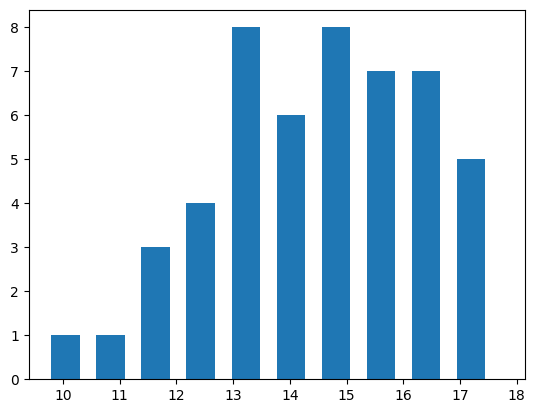

In [281]:
a4a.mean(), a4a.std(), a4a.std(ddof=1), plt.hist(a4a, width=0.5)

(np.float64(25.161000000000005),
 np.float64(2.168352600478068),
 np.float64(2.1903668968593237),
 (array([6., 4., 4., 9., 9., 5., 4., 5., 2., 2.]),
  array([21.32 , 22.192, 23.064, 23.936, 24.808, 25.68 , 26.552, 27.424,
         28.296, 29.168, 30.04 ]),
  <BarContainer object of 10 artists>))

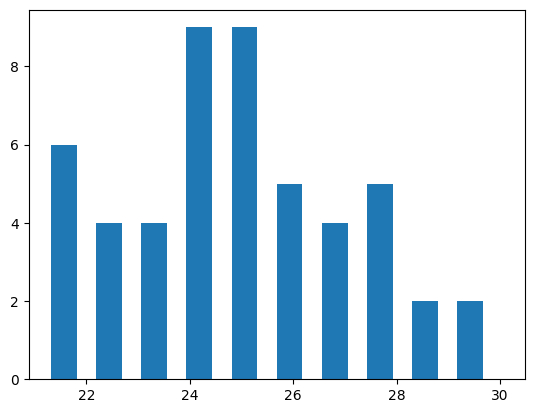

In [283]:
a4b.mean(), a4b.std(), a4b.std(ddof=1), plt.hist(a4b, width=0.5)

In [287]:
stats.ttest_ind(a4a,a4b,alternative='less')

TtestResult(statistic=np.float64(-25.958195014792874), pvalue=np.float64(5.183466875470134e-46), df=np.float64(98.0))

### 5

In [294]:
# a normal distribution
mu = 80
sigma = 20
print(f'Probability of a value less than 77.4: {1-stats.norm.sf(77.4, loc=mu, scale=sigma)}')
print(f'Probability of a value between 61.4 and 72.9: {stats.norm.sf(61.4, loc=mu, scale=sigma) - stats.norm.sf(72.9, loc=mu, scale=sigma)}')
print(f'Probability of a value greater than 90: {stats.norm.sf(90.0, loc=mu, scale=sigma)}')
print(f'Probability of a value less than 67.6 or greater than 88.8: {stats.norm.sf(88.8, loc=mu, scale=sigma) + 1 - stats.norm.sf(67.6, loc=mu, scale=sigma)}')
print(f'Probability of a value between 92.1 and 95.4: {stats.norm.sf(92.1, loc=mu, scale=sigma) - stats.norm.sf(95.4, loc=mu, scale=sigma)}')
print(f'Probability of a value between 75.0 and 84.2: {stats.norm.sf(75.0, loc=mu, scale=sigma) - stats.norm.sf(84.2, loc=mu, scale=sigma)}')

Probability of a value less than 77.4: 0.44828321334543897
Probability of a value between 61.4 and 72.9: 0.1851092533710551
Probability of a value greater than 90: 0.3085375387259869
Probability of a value less than 67.6 or greater than 88.8: 0.5975974471295767
Probability of a value between 92.1 and 95.4: 0.05193955200672762
Probability of a value between 75.0 and 84.2: 0.18187248916536608


### 6

In [295]:
stats.norm.sf(9.5, loc=10)

np.float64(0.6914624612740131)

### 7

In [299]:
# assumptions: independent random variable, normal distribution, random sampling
# cannot be hourly dependent. e.g. if the impurity is water, relative humidity varies across the day and may affect the measurements.
mu7 = 1.4
p7 = 1/6
obs7 = 1.5
obs7_2 = 1.6
sigma7 = (obs7-mu7) / stats.norm.isf(p7)
stats.norm.sf(1.6, loc=mu7, scale=sigma7)

np.float64(0.026504774191431827)

### 8

In [ ]:
# assumptions: independent random variable, weights of sccessive bags are not related (which is likely to be false)
mu8 = (49+53)/2
sigma8 = (53 - mu8) / stats.norm.isf(0.025)
sigma8

np.float64(1.0204269138493076)

In [302]:
sem8 = sigma8/np.sqrt(3)
stats.t.isf(0.025, df=2, loc=mu8, scale=sem8)

np.float64(53.534880978746656)

### 9

In [305]:
# assumptions: randomly selected each of these 16 boxes
n9 = 16
mu9 = (8.4+8.1)/2
sem9 = (8.4 - mu9) / stats.t.isf(1/40, df=15)
sigma9 = sem9 * np.sqrt(n9)
1 - stats.norm.sf(8.0, loc=mu9, scale=sigma9)

np.float64(0.18724241170905587)

### 10

In [306]:
mu10 = 3.06
sigma10 = 0.03
397 * stats.norm.sf((3.1-3.06)/0.03), 397 * (1 - stats.norm.sf((2.9-3.06)/0.03))

(np.float64(36.210854231169435), np.float64(1.91405743695805e-05))

In [308]:
# assume normal distribution
mu10_b = (2.9+3.1)/2
(3.1 - mu10_b) / stats.norm.isf(12/50)

np.float64(0.14158238304827006)

### 11

In [309]:
# assume normal distribution
mu11 = 83
sigma11 = (85-mu11) / stats.norm.isf(0.025)
sem11 = sigma11 / np.sqrt(6)
stats.t.sf(82, df=5, loc=mu11, scale=sem11) - stats.t.sf(84, df=5, loc=mu11, scale=sem11)

np.float64(0.938413923653393)

### 12

In [311]:
stats.norm.cdf(990, loc=1000, scale=10), stats.norm.sf(1010, loc=1000, scale=10), stats.norm.sf(990, loc=1000, scale=10) - stats.norm.sf(1020, loc=1000, scale=10)

(np.float64(0.15865525393145707),
 np.float64(0.15865525393145707),
 np.float64(0.8185946141203637))

### 13

In [312]:
# assumptions need randomized experiments
a13a, a13b = np.array([67,80,106,83,89]), np.array([45,71,87,53])

In [ ]:
stats.ttest_ind(a13a, a13b, alternative='two-sided') # 9.7% probability not to reject the null hypothesis

TtestResult(statistic=np.float64(1.9153196072355554), pvalue=np.float64(0.09699547999899236), df=np.float64(7.0))

In [ ]:
stats.ttest_ind(a13a, a13b, equal_var=False, alternative='two-sided') # 11.8% probability not to reject the null hypothesis

TtestResult(statistic=np.float64(1.8501424720497277), pvalue=np.float64(0.11809430504511245), df=np.float64(5.512484749147989))

### 14

In [321]:
# the difference btw the mean of two consective readings and the mean of the following two consective readings
a14 = np.array([9,10,9,8,9,8,8,8,7,6,9,10,11,9,10,11,
                11,11,11,10,11,12,13,12,13,12,14,15,14,12,13,13,
                12,13,13,13,13,13,10,8,9,8,6,7,7,6,5,6,
                5,6,4,5,4,4,2,4,5,4,5,6,5,5,6,5,
                6,7,8,8,8,7,9,10,9,10,9,8,9,8,7,7,
                8,7,7,7,8,8,8,8,7,6,5,6,5,6,7,6,
                6,5,6,6,5,4,3,4,5,5,6,5,6,7,6,5])

In [332]:
a14_diff = (a14[:-2] - a14[2:]).reshape(-1,2).sum(axis=1)
a14_diff

array([ 2,  0,  1,  3, -6, -1, -1, -1,  1, -2, -2,  0, -4,  3,  0,  1, -1,
        0,  8,  1,  4,  0,  2,  0,  2,  1,  2, -3, -2,  1, -1, -2, -3,  1,
       -4,  0,  2,  0,  3, -1,  1, -2,  0,  3,  2,  0, -2,  2, -1,  3,  2,
       -3, -1, -2,  2])

In [340]:
stats.norm.sf(8+6-3-4, loc=a14_diff.mean(), scale=a14_diff.std()) # it works

np.float64(0.0016376238087440255)

(array([ 1.,  2., 10.,  8., 10., 17.,  5.,  1.,  0.,  1.]),
 array([-6. , -4.6, -3.2, -1.8, -0.4,  1. ,  2.4,  3.8,  5.2,  6.6,  8. ]),
 <BarContainer object of 10 artists>)

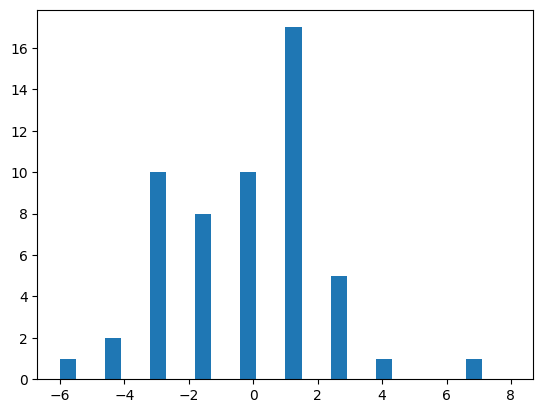

In [335]:
plt.hist(a14_diff, width=0.5)

### 15

In [341]:
# the variables have to be independent and random to perform t test
# Data taken at different times, temperature, locations might be different regardless of which stream. Flow rate
# if same day, same time, same temperature, similar and representative locations for both stream, run unpaired t test
a15a, a15b = np.array([16,12,14,11]), np.array([9,10,8,6,5])

In [342]:
stats.ttest_ind(a15a, a15b, equal_var=True), stats.ttest_ind(a15a, a15b, equal_var=False)

(TtestResult(statistic=np.float64(3.9423554608539884), pvalue=np.float64(0.005586451706978363), df=np.float64(7.0)),
 TtestResult(statistic=np.float64(3.908966098001503), pvalue=np.float64(0.007089782350290226), df=np.float64(6.339157939115644)))

### 16

In [343]:
# assumption: fully randomized location of two brands of beer
# a better test would be paired test.
# let each judge taste both brands of beer and compare. The order of the two brands of beer is fully randomized.
a16a, a16b = np.array([2,4,2,1,9,9,2,2]), np.array([8,3,5,3,7,7,4])

In [344]:
stats.ttest_ind(a16a, a16b), stats.ttest_ind(a16a, a16b, equal_var=False)

(TtestResult(statistic=np.float64(-0.9812980277363315), pvalue=np.float64(0.3443562934258946), df=np.float64(13.0)),
 TtestResult(statistic=np.float64(-1.0121829695687874), pvalue=np.float64(0.33155171710727716), df=np.float64(11.922648386730687)))

### 17

In [352]:
# test order of A and B has to be randamized for each pair
a17 = np.array([2.62,2.73,2.65,2.80,2.79,2.87,2.83,2.95,2.91,2.99,3.57,3.67]).reshape(-1,2)
a17_diffs = np.diff(a17, axis=1).reshape(-1,)
a17_diffs

array([0.11, 0.15, 0.08, 0.12, 0.08, 0.1 ])

In [358]:
stats.ttest_rel(a17[:,0], a17[:,1])

TtestResult(statistic=np.float64(-9.82872186934324), pvalue=np.float64(0.00018570285486597731), df=np.int64(5))

In [351]:
a17_diffs.mean(), a17_diffs.std(ddof=1)

(np.float64(0.10666666666666669), np.float64(0.026583202716502462))

In [ ]:
stats.ttest_1samp(a17_diffs, 0)
# the null hypothesis (the two methods has no difference) is rejected at the 0.000186 level of confidence
# to determine which method to use, tests are required to run on standard samples with known oxygen concentrations
# compare the deviation of the two methods from the standard known concentration. 

TtestResult(statistic=np.float64(9.82872186934324), pvalue=np.float64(0.00018570285486597731), df=np.int64(5))

### 18

In [355]:
# how are the smoke reading collected for both camshaft? method? conditions? Same fuel?
# are tests paired or unpaired? are tests randomized fully?
# suppose all tests were run with the same conditions. The tests were paired and the order of the two camshaft were randomized
# use paired t test 
a18 = np.array([2.7,2.6,2.9,2.6,3.2,2.9,3.5,3.3]).reshape(-1,2)
a18_diff = np.diff(a18, axis=1)
a18_diff

array([[-0.1],
       [-0.3],
       [-0.3],
       [-0.2]])

In [359]:
# null hypothesis difference = 0
stats.ttest_rel(a18[:,0], a18[:,1]), stats.ttest_1samp(a18_diff, 0)

(TtestResult(statistic=np.float64(4.700096710803845), pvalue=np.float64(0.01821985474322236), df=np.int64(3)),
 TtestResult(statistic=array([-4.70009671]), pvalue=array([0.01821985]), df=array([3])))

### 19

In [ ]:
# no need to assume normality, run independent t test
a19a, a19b = np.array([1.8,1.9,1.1,1.4]), np.array([1.9,2.1,1.5,1.5])

In [363]:
stats.ttest_ind(a19a, a19b), stats.ttest_ind(a19a, a19b, equal_var=False) # the null hypothesis is not rejected at 0.43 confidence level

(TtestResult(statistic=np.float64(-0.8401680504168049), pvalue=np.float64(0.43301141797302073), df=np.float64(6.0)),
 TtestResult(statistic=np.float64(-0.8401680504168049), pvalue=np.float64(0.4343173020288413), df=np.float64(5.756016597510373)))

### 20

In [364]:
# assume the order of measure A and B for each twin triode is fully randomized. use paired t test
a20 = np.array([1.176,1.279,1.230,1.000,1.146,1.146,1.672,1.176,0.954,0.699,1.079,1.114,1.204,1.114]).reshape(-1,2)


In [366]:
stats.ttest_rel(a20[:,0], a20[:,1]) # the null hypothesis is not rejected at a 0.14 confidence level

TtestResult(statistic=np.float64(1.6955996208936919), pvalue=np.float64(0.14089288881591178), df=np.int64(6))

### 21

In [367]:
# All corn samples were randamly selected from the same batch of corn and assigned to different methods
# The test order was fully randomized, or paired?
a21 = np.array([16,20,12,10,22,21,14,10,19,12]).reshape(-1,2)

In [369]:
# paired
stats.ttest_rel(a21[:,0], a21[:,1])

TtestResult(statistic=np.float64(1.1009637651263606), pvalue=np.float64(0.3327105135083833), df=np.int64(4))

In [371]:
# unpaired
stats.ttest_ind(a21[:,0], a21[:,1])

TtestResult(statistic=np.float64(0.6622661785325226), pvalue=np.float64(0.5264149297746109), df=np.float64(8.0))

### 22

In [380]:
# paired or unpaired?
# fully randomized?
a22 = np.array([17,11.6,22.8,11.6,21.6,13.65,20.4,17.22,11.2,8.25,14.,6.2,52.25,41.50,7.5,6.96,12.2,8.4,18.85,9.,6.05,5.18,4.05,3.]).reshape(-1,2)

In [381]:
a22[:,0].mean(), a22[:,0].std(ddof=1), a22[:,1].mean(), a22[:,1].std(ddof=1)

(np.float64(17.325),
 np.float64(12.629735835429308),
 np.float64(11.88),
 np.float64(10.103755377446186))

((array([3., 2., 2., 4., 0., 0., 0., 0., 0., 1.]),
  array([ 4.05,  8.87, 13.69, 18.51, 23.33, 28.15, 32.97, 37.79, 42.61,
         47.43, 52.25]),
  <BarContainer object of 10 artists>),
 (array([3., 4., 3., 1., 0., 0., 0., 0., 0., 1.]),
  array([ 3.  ,  6.85, 10.7 , 14.55, 18.4 , 22.25, 26.1 , 29.95, 33.8 ,
         37.65, 41.5 ]),
  <BarContainer object of 10 artists>))

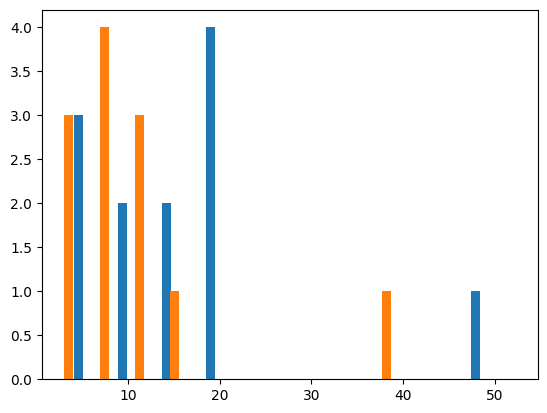

In [383]:
plt.hist(a22[:,0], width=1), plt.hist(a22[:,1], width=1)

In [384]:
# paired and randomized
# null hypothesis (no difference) is rejected at 0.00057 confidence level
stats.ttest_rel(a22[:,0], a22[:,1]) 

TtestResult(statistic=np.float64(4.785951953024206), pvalue=np.float64(0.0005659731059952906), df=np.int64(11))

In [385]:
# unpaired and randomized
# null hypothesis (no difference) is not rejected at 0.256 confidence level
stats.ttest_ind(a22[:,0], a22[:,1])

TtestResult(statistic=np.float64(1.1661995636844142), pvalue=np.float64(0.256021058747697), df=np.float64(22.0))

### 23

In [386]:
# factors that influence the performance, e.g. when to run the test (morning or afternoon) affects the performance? Weather?
# crops to be processed are randomly selected from the same field
# advice: run paired test and randomize the order (AB or BA) at the same time. Randomly select crops (which part of the field)


### 24

In [389]:
# assume independent and random variable
a24 = np.array([1.4,1.2,1.2,1.3,1.5,1.0,2.1,1.4,1.1])
mu24 = a24.mean()
sigma24 = 0.4
z24 = stats.norm.isf(0.05)

In [390]:
mu24 - sigma24 * z24,  mu24 + sigma24 * z24,  

(np.float64(0.6976141047749662), np.float64(2.0134970063361446))

In [394]:
s24 = a24.std(ddof=1)
sem24 = s24/np.sqrt(a24.shape[0])

In [395]:
sem24, stats.sem(a24)

(np.float64(0.10686324478706304), np.float64(0.10686324478706304))

In [400]:
t24 = stats.t.isf(0.05, df=a24.shape[0]-1)

In [401]:
mu24 - sem24 * t24,  mu24 + sem24 * t24,  

(np.float64(1.1568382184284491), np.float64(1.5542728926826617))

### 25

In [403]:
# assume the students were randomly assigned into 5 groups
a25 = np.array([420.6,421.,421.,420.7,420.8])

In [404]:
mu25 = a25.mean()
s25 = a25.std(ddof=1)
sem25 = s25/np.sqrt(5)
t25 = stats.t.sf(0.025, df=4)

In [405]:
mu25 - t25 * sem25, mu25 + t25 * sem25

(np.float64(420.7807499023598), np.float64(420.8592500976402))

### 26

In [406]:
a26 = np.array([166,158,174,159,150,142,166,163,165,161,178,157]).reshape(-1,2)

In [441]:
stats.ttest_ind(a26[:,0], a26[:,1]).confidence_interval(0.95)

ConfidenceInterval(low=np.float64(-1.2689211077219227), high=np.float64(20.93558777438861))

In [424]:
stats.ttest_ind(a26[:,0], a26[:,1], equal_var=False).confidence_interval(0.95)

ConfidenceInterval(low=np.float64(-1.359600183947899), high=np.float64(21.026266850614583))

In [428]:
mu26 = (a26[:,0] - a26[:,1]).mean()

In [443]:
sA26 = a26[:,0].std(ddof=1)
sB26 = a26[:,1].std(ddof=1)

In [435]:
stats.t.interval(0.95,dof)

(np.float64(-2.2281388519649385), np.float64(2.2281388519649385))

In [444]:
# equal variance
s26 = np.sqrt(((6-1)*sA26**2 + (6-1)*sB26**2)/(6-1+6-1))
se26 = s26 * np.sqrt(1/6 + 1/6)
dof26 = 6-1+6-1
mu26 + np.array(stats.t.interval(0.95, dof26)) * se26

array([-1.26892111, 20.93558777])

In [445]:
# unequal variance
se26un = np.sqrt(sA26**2/6 + sB26**2/6)
dof26un = (sA26**2/6 + sB26**2/6)**2/((sA26**2/6)**2/5 + (sB26**2/6)**2/5)
mu26 + np.array(stats.t.interval(0.95, dof26un)) * se26un

array([-1.35960018, 21.02626685])

### 27

In [446]:
a27 = np.array([3.2,2.8,2.7,2.7,3.,2.,2.7,3.,1.7,2.1,3.3,4.,2.7,1.5,2.6,2.2,2.9,2.7,3.3,2.5]).reshape(-1,2)

In [470]:
mu27 = -np.diff(a27).mean()
mu27

np.float64(0.25999999999999995)

In [461]:
stats27 = stats.ttest_ind(a27[:,0], a27[:,1], equal_var=False)

In [462]:
stats27.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(-0.2933772593133199), high=np.float64(0.8133772593133204))

In [463]:
# unequal variance due to two different species
sA27 = a27[:,0].std(ddof=1)
sB27 = a27[:,1].std(ddof=1)
se27 = np.sqrt(sA27**2/10 + sB27**2/10)
dof27 = (sA27**2/10 + sB27**2/10)**2 / ((sA27**2/10)**2/9 + (sB27**2/10)**2/9)

In [464]:
mu27 + np.array(stats.t.interval(0.95, dof27)) * se27

array([-0.29337726,  0.81337726])

### 28

In [465]:
a28 = np.array([54.6,74.9,45.8,78.3,47.4,80.4,40.1,58.7,56.3,68.1,51.5,64.7,50.7,66.5,64.5,73.5,52.6,81.,48.6,73.7]).reshape(-1,2)

In [469]:
mu28 = -np.diff(a28).mean()
mu28

np.float64(-20.77)

In [468]:
# assume unequal variance
stats28 = stats.ttest_ind(a28[:,0], a28[:,1], equal_var=False)
stats28, stats28.confidence_interval(0.95)

(TtestResult(statistic=np.float64(-6.677398097038503), pvalue=np.float64(3.064622211412024e-06), df=np.float64(17.809295095400824)),
 ConfidenceInterval(low=np.float64(-27.309922803467767), high=np.float64(-14.230077196532239)))

### 29

In [471]:
a29 = np.array([83,65,90,82,96,90,83,65,90,82]).reshape(-1,2)

In [473]:
mu29 = -np.diff(a29).mean()

In [474]:
mu29

np.float64(11.6)

In [ ]:
# if paired
stats.ttest_rel(a29[:,0], a29[:,1]) # null hypothesis is  rejected. A is better than B at 0.012 confidence level 

TtestResult(statistic=np.float64(4.396968652757639), pvalue=np.float64(0.011718811038674837), df=np.int64(4))

In [ ]:
# if not paired
stats.ttest_ind(a29[:,0], a29[:,1]) # null hypothesis is not rejected.

TtestResult(statistic=np.float64(2.0701087697199254), pvalue=np.float64(0.07221687324084633), df=np.float64(8.0))

### 30

In [478]:
# assumptions: subjects tested under similar conditions (physical, mental, and enviromental)
a30 = np.array([2.4,0.4,0.08,0.2,0.8,-0.3,2.,0.8,1.9,0,1.,np.nan]).reshape(-1,2)

In [484]:
a30[:-1,1].mean() - a30[:,0].mean()

np.float64(-1.1433333333333333)

In [482]:
# assume unequal variance
stats30 = stats.ttest_ind(a30[:-1,1], a30[:,0], equal_var=False)

In [483]:
stats30, stats30.confidence_interval(0.95), stats30.confidence_interval(0.9)

(TtestResult(statistic=np.float64(-2.8300753889357266), pvalue=np.float64(0.024078083899499766), df=np.float64(7.37013068437354)),
 ConfidenceInterval(low=np.float64(-2.088987282173524), high=np.float64(-0.19767938449314282)),
 ConfidenceInterval(low=np.float64(-1.9029879294709353), high=np.float64(-0.38367873719573187)))

### 31

In [507]:
# (a) if all fair, 
print(f'the theoritical probability of success: {2/6}')

the theoritical probability of success: 0.3333333333333333


In [515]:
# (a)
p310 = stats.binom.pmf(0,6,1/3)
p311 = stats.binom.pmf(1,6,1/3)
p312 = stats.binom.pmf(2,6,1/3)
p313 = stats.binom.pmf(3,6,1/3)
p314 = stats.binom.pmf(4,6,1/3)
p315 = stats.binom.pmf(5,6,1/3)
p316 = stats.binom.pmf(6,6,1/3)

In [516]:
fre31 = np.array([p310, p311, p312, p313, p314, p315, p316]) * 64
fre31, fre31/64

(array([ 5.61865569, 16.85596708, 21.06995885, 14.04663923,  5.26748971,
         1.05349794,  0.0877915 ]),
 array([0.0877915 , 0.26337449, 0.32921811, 0.21947874, 0.08230453,
        0.01646091, 0.00137174]))

In [517]:
success31 = np.array([0,1,2,3,4,5,6])

In [518]:
mu31 = np.average(success31, weights=fre31)
mu31

np.float64(1.9999999999999998)

In [519]:
var31 = (fre31/64 * (success31 - mu31)**2).sum()
var31

np.float64(1.3333333333333328)

In [ ]:
# 
fre31b = np.array([0,4,19,15,17,7,2])


In [521]:
mu31b = np.average(success31, weights=fre31b)
mu31b

np.float64(3.15625)

In [522]:
p31real = mu31b / 6
p31real

np.float64(0.5260416666666666)

In [527]:
var31b = (fre31b/64 * (success31 - mu31b)**2).sum() *64/63
var31b

np.float64(1.5307539682539681)

In [528]:
# (c)
stats.norm.sf(mu31b, loc=mu31, scale=np.sqrt(var31/64)) # the null hypothesis is rejected

np.float64(5.701246116322752e-16)

In [530]:
stats.chi2.sf(var31b*63/var31, df=63) # no significant different in variance

np.float64(0.19712027969877438)

In [531]:
# (d)
fre31

array([ 5.61865569, 16.85596708, 21.06995885, 14.04663923,  5.26748971,
        1.05349794,  0.0877915 ])

In [537]:
# (e)
stats.chi2.sf(((fre31 - fre31b)**2/fre31).sum(), df=63)

np.float64(4.2217951842589684e-05)

In [539]:
# (f)
fre31f = np.array([stats.binom.pmf(0,6,p31real),
stats.binom.pmf(1,6,p31real),
stats.binom.pmf(2,6,p31real),
stats.binom.pmf(3,6,p31real),
stats.binom.pmf(4,6,p31real),
stats.binom.pmf(5,6,p31real),
stats.binom.pmf(6,6,p31real)]) * 64

fre31f

array([ 0.7254725 ,  4.83116853, 13.40516542, 19.8376807 , 16.51323421,
        7.33115013,  1.3561285 ])

In [542]:
stats.chi2.sf(((fre31f-fre31b)**2/fre31f).sum(), df=62)

np.float64(1.0)

In [544]:
fre31f-fre31b

array([ 0.7254725 ,  0.83116853, -5.59483458,  4.8376807 , -0.48676579,
        0.33115013, -0.6438715 ])

In [545]:
((fre31f-fre31b)**2/fre31f).sum()

np.float64(4.718292775405966)

In [549]:
# (g) real frequency
# the possibility of x successes out of 6 is px, then the expected frequency of it is 64 * px
# number of x sccesses out 6 follows poission distrubution, mu = 64 * px, when px is small (e.g. the theoritical senario for x=5 or 6)
stats.poisson.sf(9, 64*(p315+p316))

np.float64(3.6782756013841823e-07)

### 32

In [627]:
# My first thought without hint wrongfully assume the distribution is normal distribution and it should treated as poission distribution. 
# I also misread the question. it says "number of clicks per second", not "numbers of clicks within t"
# the chance of one click per second is p, which is very small
# the number of clicks within t secondsis tp follows normal distribution
# tp is the mean, equals (16+4)/2
mu32 = (16+4)/2
sigma32 = np.sqrt((16-10) / stats.norm.isf(1/500))
mu32, sigma32

(10.0, np.float64(1.4438365361542596))

In [560]:
# p
p32 = 1 - sigma32/mu32
p32

np.float64(0.8556163463845741)

In [561]:
# t
t32 = mu32 / p32
t32

np.float64(11.687481243498004)

In [564]:
stats.norm.isf(0, loc=mu32, scale=sigma32)

np.float64(inf)

In [ ]:
# with hint
# Hint: Recall that the square root of a Poission frequency is roughly normaly distributed with standard deviation 0.5.
mu32b = (np.sqrt([16,4])).mean() # here mu32b is the mean of the square roots of the frequencies. This might NOT be correct
sigma32b = 0.5
mu32b, sigma32b

(np.float64(3.0), 0.5)

In [ ]:
stats.norm.sf(np.sqrt(16), loc=mu32b, scale=sigma32b) # which is not 0.002. meaning the mu32b is not correct

np.float64(0.0227501319481792)

In [ ]:
# try a different way

In [619]:
z32 = stats.norm.isf(1/500)
z32

np.float64(2.878161739095483)

In [620]:
# double check with 
# np.sqrt(16 * t32) - z32 * sigma32b = z32 * sigma32b + np.sqrt(4 * t32) 
t32 = (2 * z32 * sigma32b / (4 - 2)) ** 2
t32

np.float64(2.0709537490982837)

In [621]:
(np.sqrt(16 * t32) - z32 * sigma32b)**2

np.float64(18.63858374188456)

In [622]:
((4 + 2) * np.sqrt(2.25)/2)**2 # test with the given t32 = 2.25 in the hint

np.float64(20.25)

### 33

In [631]:
# poisson distribution mu = np
mu33 = ((np.sqrt(16*t32) + np.sqrt(4*t32))/2)**2
mu33

np.float64(18.63858374188456)

In [634]:
stats.poisson.isf(1/500, mu=mu33) / 16, stats.poisson.sf(16*t32, mu=mu33)

(np.float64(2.0), np.float64(0.000883696983646906))

In [637]:
stats.poisson.isf(1-1/500, mu=mu33) / 4, 1- stats.poisson.sf(4*t32, mu=mu33)

(np.float64(2.0), np.float64(0.004821606111943488))

### 34

In [639]:
a34 = np.array([24,10,41,
25,13,32,
12,20,9]).reshape(3,3)
a34

array([[24, 10, 41],
       [25, 13, 32],
       [12, 20,  9]])

In [646]:
a34no = a34[:,[0]]
a34th = a34[:,[1,2]].sum(axis=1, keepdims=True)
a34g = a34[:,[1]]
a34i = a34[:,[2]]
a34no, a34th, a34g, a34i

(array([[24],
        [25],
        [12]]),
 array([[51],
        [45],
        [29]]),
 array([[10],
        [13],
        [20]]),
 array([[41],
        [32],
        [ 9]]))

Questions:
1. Overall differences among all 3?
2. no vs therapy
3. no vs group
4. no vs individual
5. group vs individual


In [653]:
# Q1: overall yes difference
stats.chi2_contingency(a34), stats.chi2_contingency(a34).expected_freq/a34.sum()

(Chi2ContingencyResult(statistic=np.float64(22.26641356487144), pvalue=np.float64(0.00017737210809261862), dof=4, expected_freq=array([[24.59677419, 17.33870968, 33.06451613],
        [22.95698925, 16.1827957 , 30.86021505],
        [13.44623656,  9.47849462, 18.07526882]])),
 array([[0.13224072, 0.09321887, 0.17776622],
        [0.12342467, 0.08700428, 0.16591513],
        [0.07229159, 0.05095965, 0.09717886]]))

In [ ]:
# Q2: no vs therapy, no difference
stats.chi2_contingency(np.concat((a34no, a34th), axis=1))


Chi2ContingencyResult(statistic=np.float64(0.5235461746729879), pvalue=np.float64(0.7696856553158751), dof=2, expected_freq=array([[24.59677419, 50.40322581],
       [22.95698925, 47.04301075],
       [13.44623656, 27.55376344]]))

In [648]:
# Q3: no vs group, yes difference
stats.chi2_contingency(np.concat((a34no, a34g), axis=1))

Chi2ContingencyResult(statistic=np.float64(8.6993906015965), pvalue=np.float64(0.01291074587517573), dof=2, expected_freq=array([[19.94230769, 14.05769231],
       [22.28846154, 15.71153846],
       [18.76923077, 13.23076923]]))

In [650]:
# Q4: no vs individual, no difference
stats.chi2_contingency(np.concat((a34no, a34i), axis=1))

Chi2ContingencyResult(statistic=np.float64(2.7088775517361974), pvalue=np.float64(0.25809210132898674), dof=2, expected_freq=array([[27.72727273, 37.27272727],
       [24.31468531, 32.68531469],
       [ 8.95804196, 12.04195804]]))

In [651]:
# Q5: group vs individual, yes difference
stats.chi2_contingency(np.concat((a34g, a34i), axis=1))

Chi2ContingencyResult(statistic=np.float64(20.904722585600304), pvalue=np.float64(2.8879998588908722e-05), dof=2, expected_freq=array([[17.544, 33.456],
       [15.48 , 29.52 ],
       [ 9.976, 19.024]]))